# 简单 ResNet模型
参数：1,255,182

1. 采用**分层采样**：“每个手指固定 6 张训练、2 张测试”
能确保模型在训练时见过每一个手指，在测试时也能评估每一个手指。
2. 训练集：测试集 = 6:2，保持了合理的训练数据量，同时保证了测试的代表性。
3. **使用LR=0.001并进行学习率衰退**

**Result: 84.09%的测试准确率**

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
import matplotlib.pyplot as plt
from PIL import Image

from torch.utils.data import Subset
from collections import defaultdict
import random

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
device

device(type='cuda')

## 1. 读取指纹数据

In [4]:
class FVC2002Dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        # 过滤出所有的 .tif 文件
        self.image_files = [f for f in os.listdir(root_dir) if f.endswith('.tif')]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.root_dir, img_name)
        
        # 加载图像并转为灰度图（指纹图通常是单通道）
        image = Image.open(img_path).convert('L')
        
        # 解析标签：例如 "10_3.tif" -> 标签为 10
        # 注意：类别索引通常从 0 开始，所以我们将 ID 减 1
        label = int(img_name.split('_')[0]) - 1
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [5]:
# 临时加载数据集（仅 ToTensor）
dataset = FVC2002Dataset(root_dir='../FVC2002/Db1',
                        transform=transforms.Compose([
                        transforms.Grayscale(),
                        transforms.ToTensor()
                               ]))
loader = DataLoader(dataset, batch_size=100, shuffle=False)

def get_mean_and_std(loader):
    mean = 0.
    std = 0.
    total_images_count = 0
    for images, _ in loader:
        image_count_in_batch = images.size(0)
        images = images.view(image_count_in_batch, images.size(1), -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        total_images_count += image_count_in_batch
    mean /= total_images_count
    std /= total_images_count
    return mean, std

mean, std = get_mean_and_std(loader)
print(f"Mean: {mean}, Std: {std}")

Mean: tensor([0.8499]), Std: tensor([0.2375])


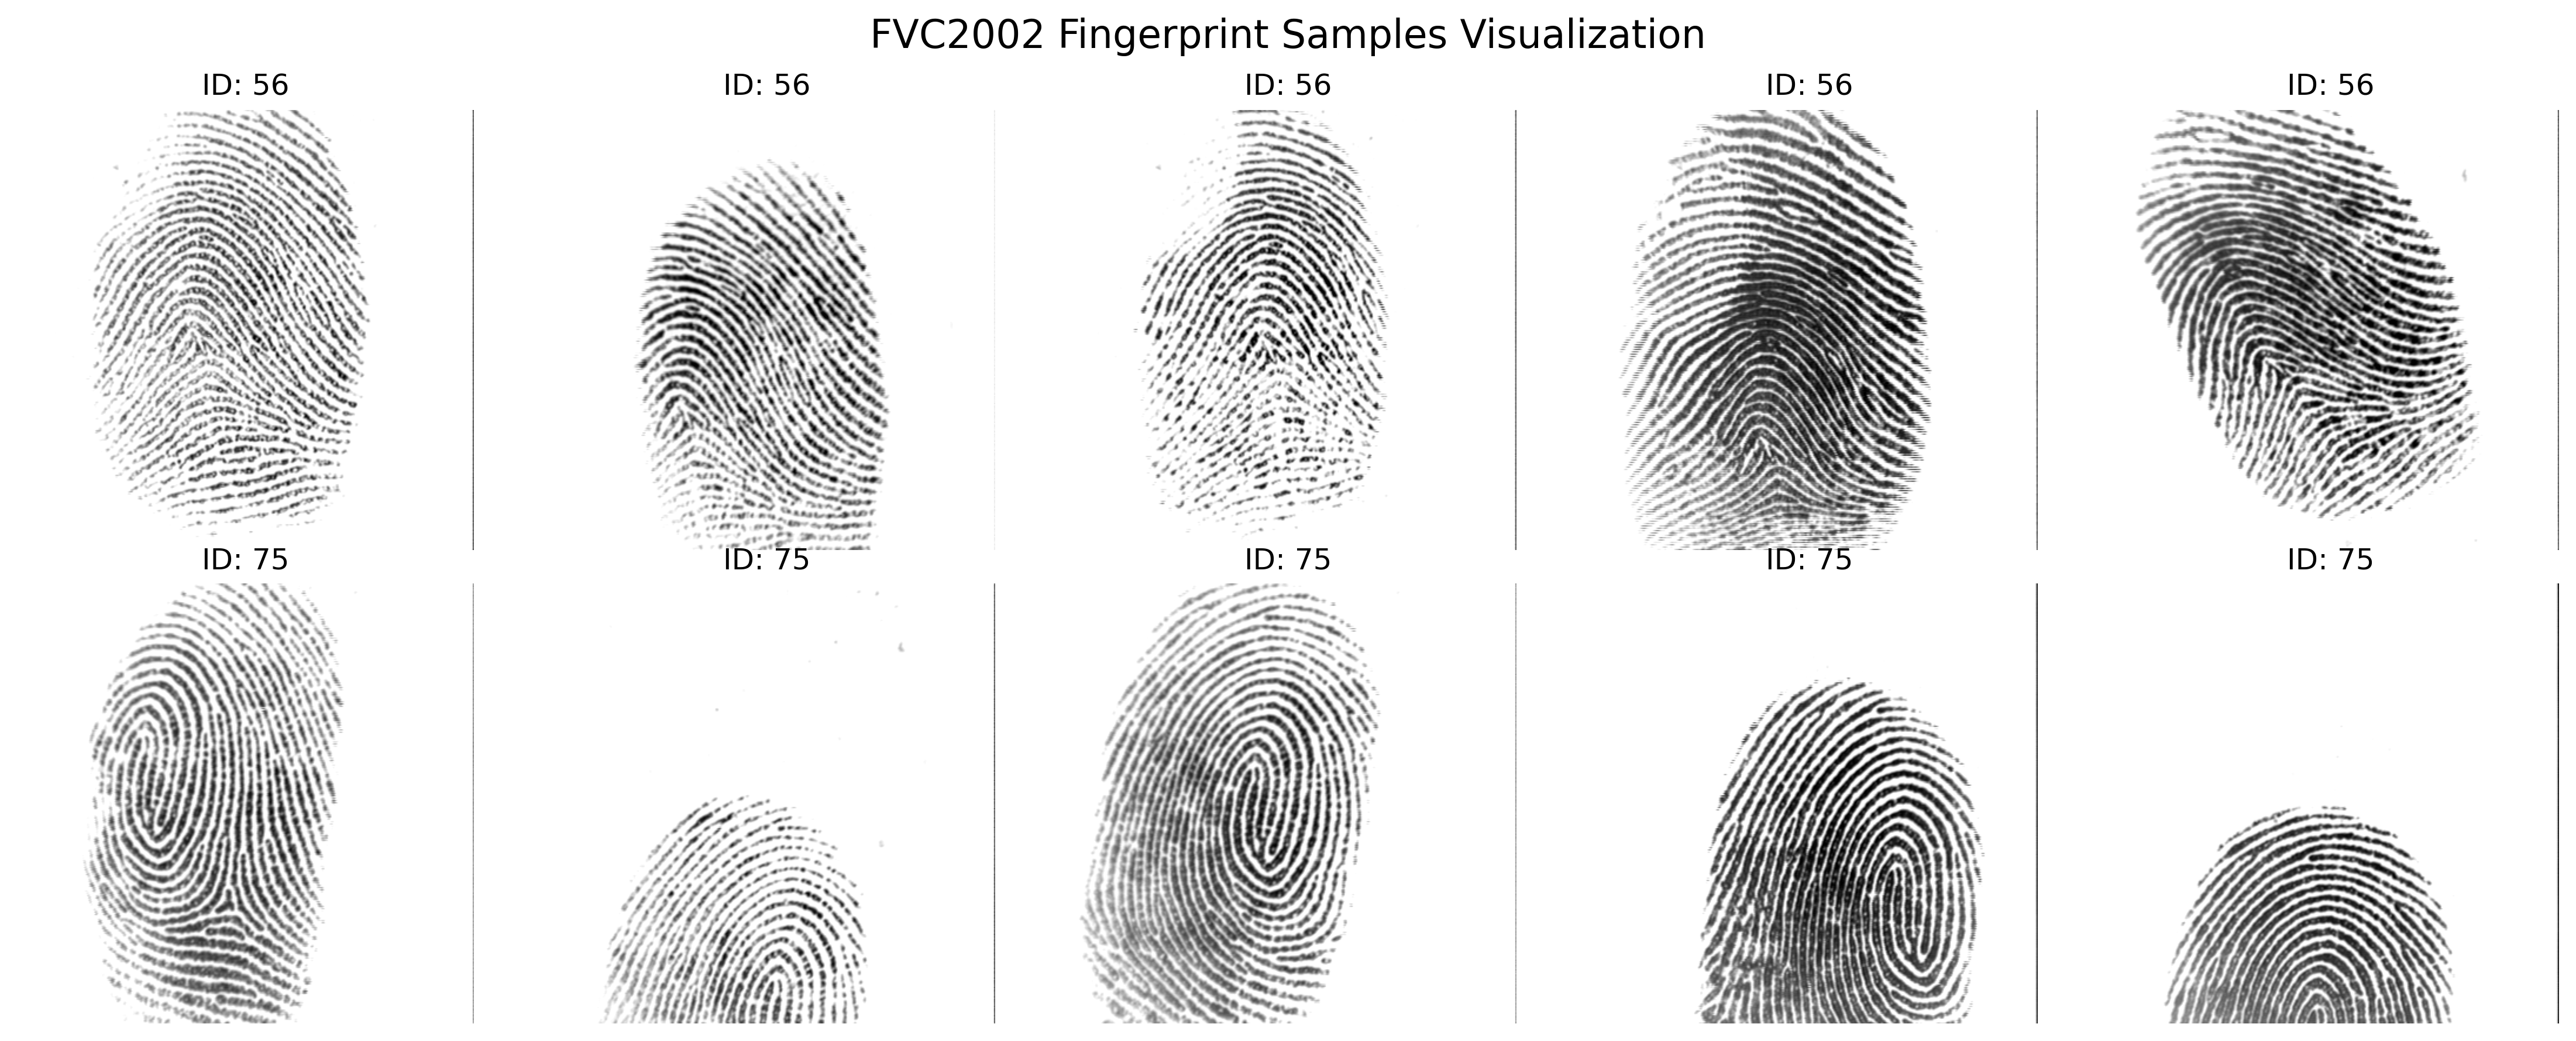

In [6]:
# 指纹图片查看
def visualize_fvc_samples(dataset, num_people=2, samples_per_person=5):
    # 1. 建立 ID 到 索引列表的映射
    # label 是 img_name.split('_')[0] - 1
    id_to_indices = {}
    for idx, img_name in enumerate(dataset.image_files):
        label = int(img_name.split('_')[0]) - 1
        if label not in id_to_indices:
            id_to_indices[label] = []
        id_to_indices[label].append(idx)

    # 2. 随机抽取指定数量的人
    selected_ids = random.sample(list(id_to_indices.keys()), num_people)

    # 3. 开始绘图
    fig, axes = plt.subplots(num_people, samples_per_person, figsize=(15, 6), dpi=300)
    fig.suptitle('FVC2002 Fingerprint Samples Visualization', fontsize=16)

    for i, person_id in enumerate(selected_ids):
        # 随机抽取该人的 5 个指纹索引
        indices = random.sample(id_to_indices[person_id], samples_per_person)
        
        for j, idx in enumerate(indices):
            image, label = dataset[idx]
            
            # 如果 image 是 Tensor (经过了 transform)，需要转回 numpy
            if torch.is_tensor(image):
                image = image.squeeze().numpy() # 移除通道维度 [1, H, W] -> [H, W]
            
            ax = axes[i, j] if num_people > 1 else axes[j]
            ax.imshow(image, cmap='gray')
            ax.set_title(f"ID: {person_id + 1}")
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# 使用方法：
visualize_fvc_samples(dataset, num_people=2, samples_per_person=5)

In [7]:
class ApplyTransform(Dataset):
    """
    一个简单的装饰器类，用于给 Subset 应用特定的 transform
    """
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.subset)

# 1. 定义两个不同的 Pipeline
# 基础操作（训练和测试共有）
base_ops = [
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.85], std=[0.2375])
]

# 训练集特有：加入随机旋转
train_transforms = transforms.Compose([
    transforms.RandomRotation(15),
    *base_ops
])

# 测试集：仅基础操作
test_transforms = transforms.Compose(base_ops)

# 2. 原始数据集加载时不带 transform (或者只带 Resize)
full_dataset = FVC2002Dataset(root_dir='../FVC2002/Db1', transform=None)

# --- 2. 建立标签到索引的映射 (字典结构) ---
# 这一步是为了找出每个手指对应的 8 张图分别在列表的哪个位置
label_to_indices = defaultdict(list)
for idx, img_name in enumerate(full_dataset.image_files):
    # 使用与你 Dataset 类中一致的解析逻辑
    label = int(img_name.split('_')[0]) - 1
    label_to_indices[label].append(idx)

train_indices = []
test_indices = []

# --- 3. 核心：对每一个类别固定分配 6/2 ---
# 确保每个类（手指）都参与了划分
for label, indices in label_to_indices.items():
    # 随机打乱当前手指的 8 张图索引
    random.shuffle(indices)
    
    # 取前 6 张作为训练，后 2 张作为测试
    train_indices.extend(indices[:6])
    test_indices.extend(indices[6:])

# --- 4. 创建 Subset 并应用不同的 Transform ---
# 先利用索引创建子集
train_subset = Subset(full_dataset, train_indices)
test_subset = Subset(full_dataset, test_indices)
# 5. 分别包装，应用不同的 transform
train_dataset = ApplyTransform(train_subset, transform=train_transforms)
test_dataset = ApplyTransform(test_subset, transform=test_transforms)

In [8]:
len(train_dataset), len(test_dataset)

(660, 220)

In [9]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## 2. 构建模型

In [10]:
def conv3x3(in_planes, out_planes, stride=1):
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=1, bias=False)

class TinyBlock(nn.Module):
    """精简版残差块"""
    def __init__(self, in_planes, planes, stride=1):
        super(TinyBlock, self).__init__()
        self.conv1 = conv3x3(in_planes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class TinyFingerResNet(nn.Module):
    def __init__(self, num_classes=110):
        super(TinyFingerResNet, self).__init__()
        self.in_planes = 32

        # 1. Stem层: 针对384x384输入，先进行一定的下采样
        # 384 -> 192
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        
        # 2. ResNet Stages
        # Stage 1: 192 -> 96
        self.layer1 = self._make_layer(32, stride=2)
        # Stage 2: 96 -> 48
        self.layer2 = self._make_layer(64, stride=2)
        # Stage 3: 48 -> 24
        self.layer3 = self._make_layer(128, stride=2)
        # Stage 4: 24 -> 12
        self.layer4 = self._make_layer(256, stride=2)

        # 3. 分类头
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.5) # 增加Dropout防止过拟合
        self.fc = nn.Linear(256, num_classes)

    def _make_layer(self, planes, stride):
        layers = []
        layers.append(TinyBlock(self.in_planes, planes, stride))
        self.in_planes = planes
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.dropout(out)
        out = self.fc(out)
        return out

## 3. 模型训练

In [11]:
# 1. 训练一个 Epoch 的函数
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    train_loss = running_loss / len(loader)
    train_acc = 100. * correct / total
    return train_loss, train_acc

In [12]:
# 2. 验证/测试函数 (基于你提供的 evaluate 修改)
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    val_loss = running_loss / len(loader)
    val_acc = 100. * correct / total
    return val_loss, val_acc

In [13]:
# 3. 总训练控制函数
def train(model, train_loader, test_loader, criterion, optimizer, device, scheduler=None, epochs=20):
    # 用于记录历史数据以便绘图
    history = {
        'train_loss': [], 'train_acc': [],
        'test_loss': [], 'test_acc': []
    }
    
    print(f"开始训练，设备: {device}")
    for epoch in range(epochs):
        # 训练阶段
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        # 验证阶段
        test_loss, test_acc = validate(model, test_loader, criterion, device)
        
        # 每个 epoch 结束更新学习率
        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(test_acc)  # 以验证准确率为指标调整学习率
            else:
                scheduler.step()  # 其他类型的调度器直接调用 step()
            current_lr = optimizer.param_groups[0]['lr']

        # 记录历史
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        
        print(f"[Epoch {epoch+1}/{epochs}](LR: {current_lr:.6f}) -> "
              f"Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}% | "
              f"Train Loss: {train_loss:.4f}")

    # 训练结束后进行可视化
    plot_history(history)
    return history

# 4. 可视化函数
def plot_history(history):
    epochs = range(1, len(history['train_acc']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # 绘制准确率曲线
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_acc'], 'b-', label='Training Acc')
    plt.plot(epochs, history['test_acc'], 'r-', label='Test Acc')
    plt.title('Training and Test Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    
    # 绘制损失曲线
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_loss'], 'b-', label='Training Loss')
    plt.plot(epochs, history['test_loss'], 'r-', label='Test Loss')
    plt.title('Training and Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

### 3.1 Simple ResNet模型

##### 余弦退火

总参数量: 1,255,182
开始训练，设备: cuda
[Epoch 1/100](LR: 0.001000) -> Train Acc: 0.00%, Test Acc: 0.91% | Train Loss: 4.8839
[Epoch 2/100](LR: 0.000999) -> Train Acc: 1.82%, Test Acc: 4.09% | Train Loss: 4.5910
[Epoch 3/100](LR: 0.000998) -> Train Acc: 3.03%, Test Acc: 4.09% | Train Loss: 4.4478
[Epoch 4/100](LR: 0.000996) -> Train Acc: 5.45%, Test Acc: 1.36% | Train Loss: 4.2409
[Epoch 5/100](LR: 0.000994) -> Train Acc: 6.82%, Test Acc: 5.45% | Train Loss: 4.1121
[Epoch 6/100](LR: 0.000991) -> Train Acc: 7.12%, Test Acc: 9.55% | Train Loss: 3.9311
[Epoch 7/100](LR: 0.000988) -> Train Acc: 9.39%, Test Acc: 8.64% | Train Loss: 3.7477
[Epoch 8/100](LR: 0.000984) -> Train Acc: 12.88%, Test Acc: 13.64% | Train Loss: 3.5632
[Epoch 9/100](LR: 0.000980) -> Train Acc: 14.24%, Test Acc: 10.00% | Train Loss: 3.4378
[Epoch 10/100](LR: 0.000976) -> Train Acc: 15.76%, Test Acc: 12.27% | Train Loss: 3.3238
[Epoch 11/100](LR: 0.000971) -> Train Acc: 19.39%, Test Acc: 15.91% | Train Loss: 3.1906
[Epoch 12/100]

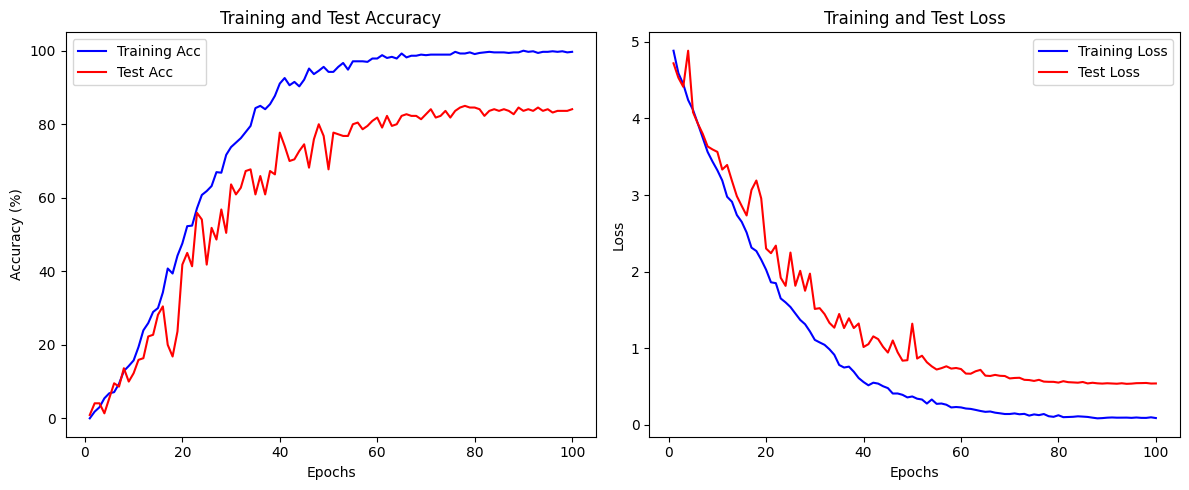

In [14]:
simple_resnet = TinyFingerResNet(num_classes=110).to(device)
optimizer = optim.Adam(simple_resnet.parameters(), lr=0.001)
# 进行学习率衰退, 使用CosineAnnealingLR
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-5)
criterion = nn.CrossEntropyLoss()
total_params = sum(p.numel() for p in simple_resnet.parameters())
print(f"总参数量: {total_params:,}")
history1 = train(simple_resnet, train_loader, test_loader, criterion, optimizer, device, scheduler, epochs=100)

##### ReduceLROnPlateau

总参数量: 1,255,182
开始训练，设备: cuda
[Epoch 1/100](LR: 0.001000) -> Train Acc: 0.91%, Test Acc: 1.36% | Train Loss: 4.8387
[Epoch 2/100](LR: 0.001000) -> Train Acc: 1.82%, Test Acc: 3.64% | Train Loss: 4.6225
[Epoch 3/100](LR: 0.001000) -> Train Acc: 3.18%, Test Acc: 3.18% | Train Loss: 4.4430
[Epoch 4/100](LR: 0.001000) -> Train Acc: 5.30%, Test Acc: 1.82% | Train Loss: 4.2799
[Epoch 5/100](LR: 0.001000) -> Train Acc: 6.82%, Test Acc: 4.55% | Train Loss: 4.0513
[Epoch 6/100](LR: 0.001000) -> Train Acc: 10.15%, Test Acc: 5.00% | Train Loss: 3.8774
[Epoch 7/100](LR: 0.001000) -> Train Acc: 10.30%, Test Acc: 10.91% | Train Loss: 3.7062
[Epoch 8/100](LR: 0.001000) -> Train Acc: 11.52%, Test Acc: 11.82% | Train Loss: 3.5410
[Epoch 9/100](LR: 0.001000) -> Train Acc: 13.03%, Test Acc: 15.00% | Train Loss: 3.4489
[Epoch 10/100](LR: 0.001000) -> Train Acc: 16.21%, Test Acc: 16.82% | Train Loss: 3.2753
[Epoch 11/100](LR: 0.001000) -> Train Acc: 16.67%, Test Acc: 19.55% | Train Loss: 3.1733
[Epoch 12/1

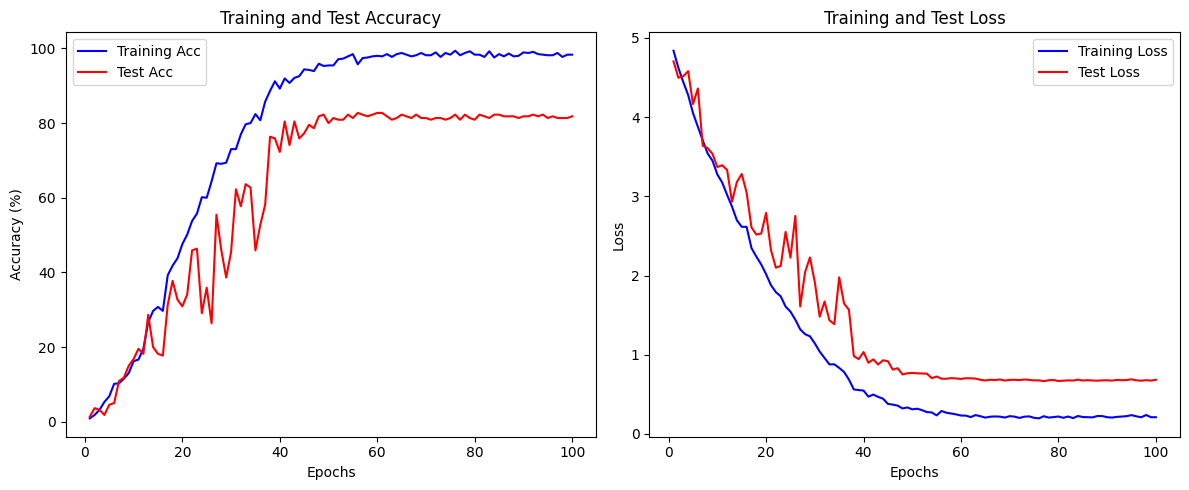

In [15]:
simple_resnet = TinyFingerResNet(num_classes=110).to(device)
optimizer = optim.Adam(simple_resnet.parameters(), lr=0.001)
# 进行学习率衰退, 使用CosineAnnealingLR
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, verbose=True)
criterion = nn.CrossEntropyLoss()
total_params = sum(p.numel() for p in simple_resnet.parameters())
print(f"总参数量: {total_params:,}")
history2 = train(simple_resnet, train_loader, test_loader, criterion, optimizer, device, scheduler, epochs=100)